## 1. Configuración Inicial y Carga de Datos

### Vamos a trabajar con el dataset de IBM HR Analytics, que contiene información de 1,470 empleados con 35 variables cada uno. El objetivo es entender qué factores llevan a un empleado a renunciar a su empleo. Empezamos con la configuración inicial

In [13]:
# En este paso importamos las librerías necesarias para el análisis de datos, la visualización y el preprocesamiento. 
# Luego, cargamos el dataset de empleados y realizamos una inspección inicial para entender su estructura y contenido.

import numpy as np # Para operaciones numéricas
import pandas as pd # Para manipulación de datos    
import matplotlib.pyplot as plt # Para visualización de datos
import seaborn as sns # Para visualización de datos con estilos
from scipy import stats # Para análisis estadístico
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder # Para preprocesamiento de datos
from sklearn.decomposition import PCA # Para reducción de dimensionalidad
import warnings # Para manejar advertencias y evitar que se muestren en la salida
warnings.filterwarnings('ignore') # Ignorar advertencias para una salida más limpia

# Configuramos el estilo de los gráficos y el tamaño de las figuras para una mejor visualización.
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted") # Establece el tema de Seaborn para gráficos con fondo blanco y paleta de colores suave
plt.rcParams['figure.figsize'] = (12, 6) # Establece el tamaño predeterminado de las figuras a 12 pulgadas de ancho y 6 pulgadas de alto
plt.rcParams['axes.titlesize'] = 16 # Establece el tamaño de los títulos de los ejes a 16 puntos

# Cargcargamos el  dataset
df = pd.read_csv('../WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Inspeccionamos inicialmente el dataset para entender su estructura y contenido
print(f"Dimensiones del dataset: {df.shape}")
print(f"Filas: {df.shape[0]} empleados | Columnas: {df.shape[1]} variables")
print("\n--- Primeras filas del data set de empleados ---")
df.head() # Muestra las primeras filas del dataset para una vista previa de los datos

Dimensiones del dataset: (1470, 35)
Filas: 1470 empleados | Columnas: 35 variables

--- Primeras filas del data set de empleados ---


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


#### Con info() vemos los tipos de datos de cada columna. Tenemos 26 variables numéricas y 9 categóricas. Esto ya nos dice qué tipo de tratamiento va a necesitar cada una más adelante.

In [14]:
# Revisión rápida de tipos de datos
print("Tipos de datos por columna:")
df.info()

Tipos de datos por columna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 

---
## Fase 2: Análisis Exploratorio de Datos (EDA)

### Revisamos si hay datos ausentes. El resultado es cero nulos en todo el dataset, lo cual es bastante inusual y habla bien de la calidad de los datos. Aun así documentamos la estrategia que aplicaríamos si existieran: eliminación para menos del 5%, imputación con media o mediana para variables numéricas según su sesgo, y moda para categóricas

### 2.1 Valores faltantes

In [16]:
# Cuenta el número de valores nulos en cada columna del DataFrame
null_counts = df.isnull().sum() 
# Calcula el porcentaje de valores nulos en cada columna dividiendo el conteo de nulos por el número total de filas y multiplicando por 100
null_pct = (null_counts / len(df)) * 100 
# Combina el conteo de nulos y el porcentaje en un nuevo DataFrame llamado missing_df, con columnas 'Total_Nulos' y 'Porcentaje (%)'
missing_df = pd.concat([null_counts, null_pct], axis=1, keys=['Total_Nulos', 'Porcentaje (%)']) 

print("=" * 45)
print("   ANÁLISIS DE VALORES FALTANTES")
print("=" * 45)
cols_con_nulos = missing_df[missing_df['Total_Nulos'] > 0]

if cols_con_nulos.empty:
    print("✓ El dataset NO presenta valores nulos en ninguna columna.")
    print(f"  Total de celdas revisadas: {df.shape[0] * df.shape[1]:,}")
else:
    print(cols_con_nulos)

# Estrategia de tratamiento propuesta en caso de que existan valores faltantes en el dataset, dependiendo del porcentaje de nulos y su distribución.


   ANÁLISIS DE VALORES FALTANTES
✓ El dataset NO presenta valores nulos en ninguna columna.
  Total de celdas revisadas: 51,450


#### En caso de existir valores faltantes, la estrategia dependería del porcentaje:

  • < 5% y distribución aleatoria (MCAR) → Eliminación de filas afectadas.
    Ejemplo: 3 registros sin edad → se eliminan sin impacto estadístico.

  • 5–30% → Imputación:
      - Variables numéricas simétricas: imputar con la MEDIA.
      - Variables numéricas con sesgo:  imputar con la MEDIANA.
      - Variables categóricas:          imputar con la MODA.

  • > 30% → Evaluar si el patrón de ausencia es informativo. En ese caso,
    se crearía una columna binaria 'Es_Nulo_X' que capture ese patrón,
    y se aplicaría imputación para el valor original.


### 2.2 Detección de Valores Atípicos (Outliers)

Un **outlier** es un valor que se aleja mucho del resto. Pueden ser errores de medición o datos reales pero extremos (ej. un CEO con un salario 10 veces mayor al promedio).

**Métodos utilizados:**
- **Boxplot**: gráfico de caja. Los puntos fuera de los "bigotes" son potenciales outliers.
- **IQR (Rango Intercuartílico)**: matemáticamente define como outlier cualquier valor fuera de `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]`.
- **Z-score**: mide cuántas desviaciones estándar se aleja un punto de la media. Valores > 3 son outliers.

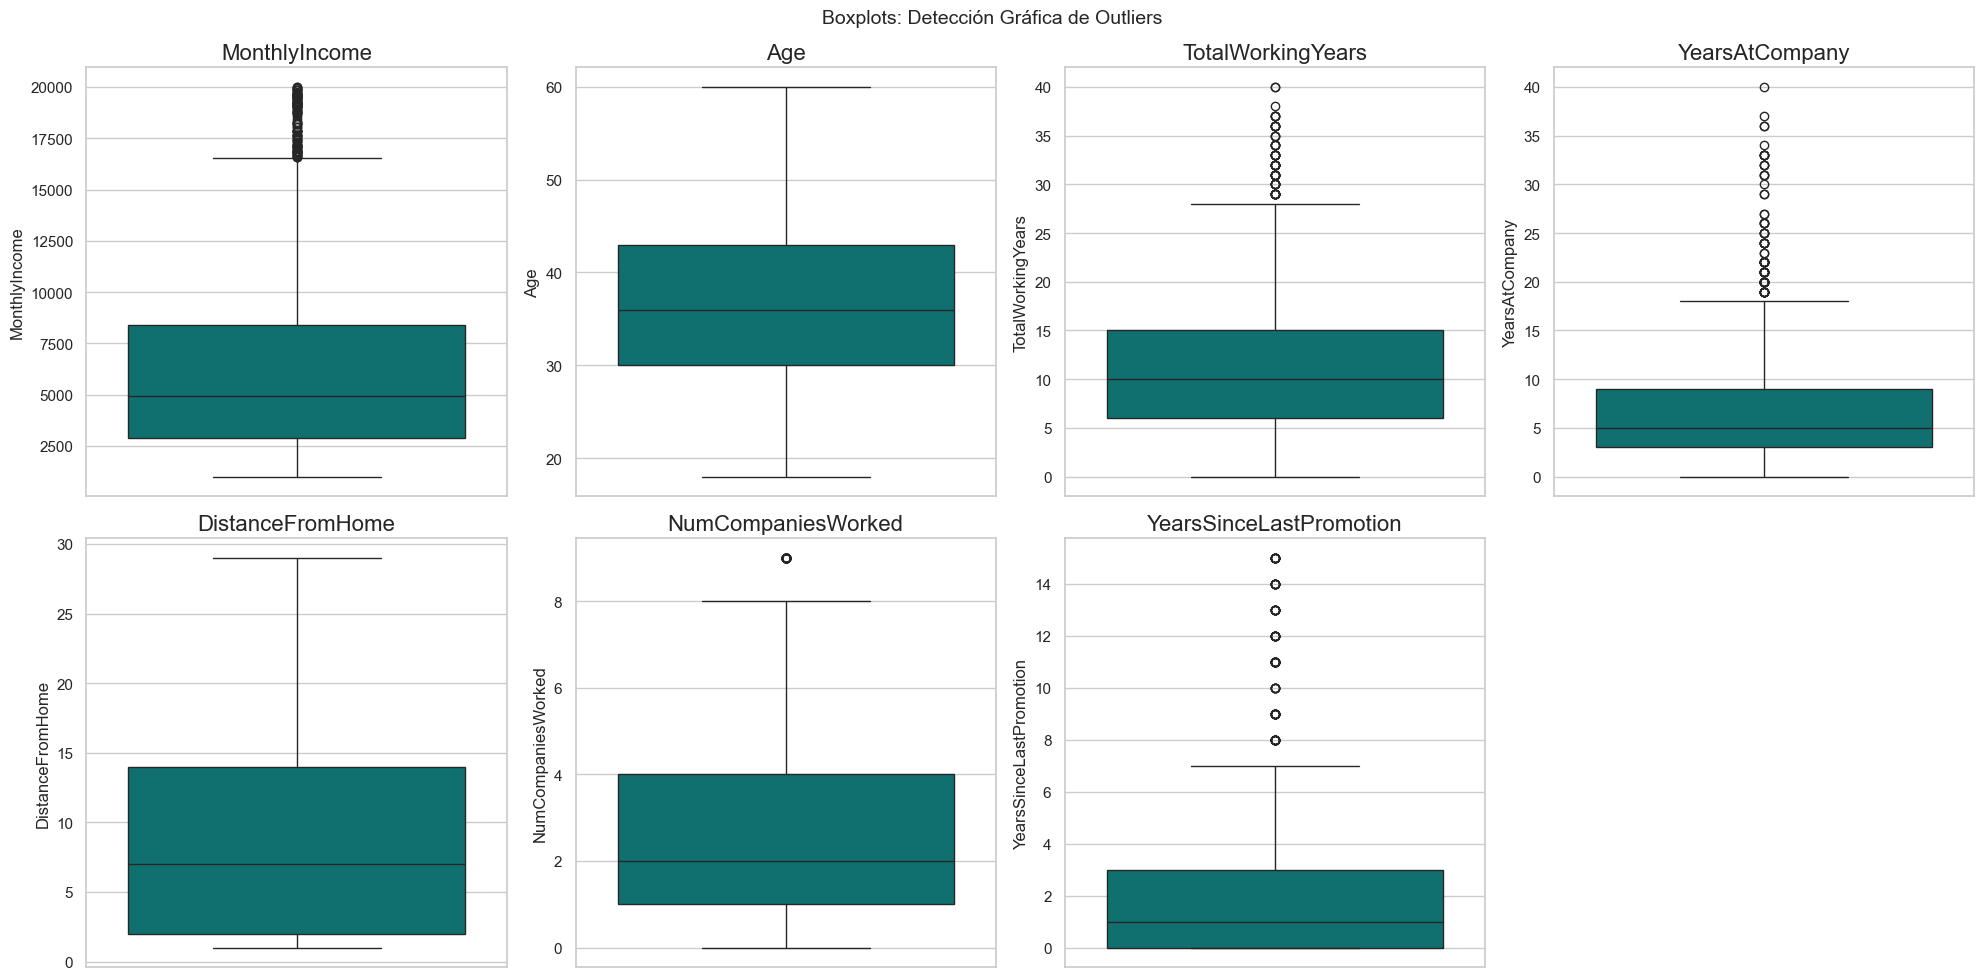

In [18]:
# Variables numéricas clave para análisis de outliers
# Estas variables se seleccionan por su relevancia en el contexto de recursos humanos y 
# su potencial para contener valores atípicos que podrían influir en el análisis de la rotación de empleados.
outlier_vars = ['MonthlyIncome', 'Age', 'TotalWorkingYears', 'YearsAtCompany',
                'DistanceFromHome', 'NumCompaniesWorked', 'YearsSinceLastPromotion']

# --- Boxplots ---
fig, axes = plt.subplots(2, 4, figsize=(20, 10)) # Crea una figura con una cuadrícula de 2 filas y 4 columnas para mostrar los boxplots de las variables seleccionadas
axes = axes.flatten() # Aplana la matriz de ejes para facilitar la iteración

for i, col in enumerate(outlier_vars): # Itera sobre las variables seleccionadas para crear un boxplot para cada una
    sns.boxplot(y=df[col], ax=axes[i], color='teal')
    axes[i].set_title(col)

axes[-1].set_visible(False)  # Ocultar el eje vacío
plt.suptitle('Boxplots: Detección Gráfica de Outliers', fontsize=14)
plt.tight_layout()
plt.show()

In [22]:
Analisis_de_outliers = """
Análisis de los boxplots (outliers) para las variables numéricas clave:

- MonthlyIncome: hay 114 valores por encima del límite superior (16581), ~7.8% del dataset.
    Esto indica un grupo de empleados con ingresos muy altos respecto al resto.

- Age: no hay outliers según IQR (ningún valor fuera de [10.5, 62.5]), es un rango controlado.

- TotalWorkingYears: 63 outliers (>28.5 años), ~4.3%. Son trabajadores con trayectorias laborales muy largas.

- YearsAtCompany: 104 outliers (>18 años), ~7.1%. Empleados de larga permanencia en la compañía.

- DistanceFromHome: 0 outliers, la mayoría vive a distancias razonables (<=32 km).

- NumCompaniesWorked: 52 outliers (>8.5 empresas), ~3.5%. Se trata de empleados con historial laboral muy rotativo.

- YearsSinceLastPromotion: 107 outliers (>7.5 años), ~7.3%. Pueden indicar estancamiento en el desarrollo interno.

Conclusión:
1) Variables con mayor proporción de outliers: MonthlyIncome, YearsAtCompany, YearsSinceLastPromotion.
2) No se detectan outliers extremos en Age y DistanceFromHome.
3) La presencia de outliers en ingresos y años de servicio puede influir en el análisis de rotación, por lo que podriamos considerar técnicas de tratamiento .
"""
print(Analisis_de_outliers)


Análisis de los boxplots (outliers) para las variables numéricas clave:

- MonthlyIncome: hay 114 valores por encima del límite superior (16581), ~7.8% del dataset.
    Esto indica un grupo de empleados con ingresos muy altos respecto al resto.

- Age: no hay outliers según IQR (ningún valor fuera de [10.5, 62.5]), es un rango controlado.

- TotalWorkingYears: 63 outliers (>28.5 años), ~4.3%. Son trabajadores con trayectorias laborales muy largas.

- YearsAtCompany: 104 outliers (>18 años), ~7.1%. Empleados de larga permanencia en la compañía.

- DistanceFromHome: 0 outliers, la mayoría vive a distancias razonables (<=32 km).

- NumCompaniesWorked: 52 outliers (>8.5 empresas), ~3.5%. Se trata de empleados con historial laboral muy rotativo.

- YearsSinceLastPromotion: 107 outliers (>7.5 años), ~7.3%. Pueden indicar estancamiento en el desarrollo interno.

Conclusión:
1) Variables con mayor proporción de outliers: MonthlyIncome, YearsAtCompany, YearsSinceLastPromotion.
2) No se detecta

### 2.3 Análisis de Distribuciones
Acá realizamos un análisis de distribuciones sobre las variables numéricas Age, MonthlyIncome, DistanceFromHome y TotalWorkingYears utilizando histogramas con curvas de densidad. Este análisis nos ayuda observar la forma de los datos y a identificar posibles sesgos o comportamientos no normales. 
Se encontró que algunas variables presentan asimetría positiva, especialmente MonthlyIncome, lo que indica que la mayoría de los empleados tiene ingresos bajos y pocos presentan valores altos. Este comportamiento puede requerir transformaciones en etapas posteriores del análisis.

In [ ]:
num_cols = ['Age', 'MonthlyIncome', 'DistanceFromHome', 'TotalWorkingYears']

plt.figure(figsize=(15, 12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, color='purple')
    plt.title(f'Distribución de {col} (Sesgo: {df[col].skew():.2f})')

plt.tight_layout()
plt.show()

# Transformación sugerida:
# MonthlyIncome tiene un sesgo alto (1.37). Podría beneficiarse de una transformación logarítmica.

### 2.4 Análisis Univariado (Categóricas)
El análisis univariado se aplicó a variables categóricas como BusinessTravel, Department, EducationField, Gender, JobRole, MaritalStatus y OverTime, utilizando gráficos de barras para visualizar la frecuencia de cada categoría. 
Este análisis  nos permite entender la distribución individual de cada variable y detectar posibles desbalances en los datos. Logramos observar que algunas categorías tienen mayor representación que otras, lo cual es importante considerar para la interpretación de resultados y futuros modelos.


In [ ]:
cat_cols = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

plt.figure(figsize=(15, 20))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(4, 2, i)
    sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='magma')
    plt.title(f'Frecuencia de {col}')

plt.tight_layout()
plt.show()

### 2.5 Análisis Multivariado y Relaciones
Realizamos un análisis multivariado para explorar relaciones entre variables, enfocándose en 'Attrition', que indica la rotación de empleados. Se utilizó una tabla cruzada entre OverTime y Attrition, observando que los empleados que trabajan horas extra presentan mayor proporción de abandono. Además, se generó una matriz de correlación para las variables numéricas, donde se identificó relación positiva entre Age, TotalWorkingYears y MonthlyIncome, lo que indica que la experiencia y la edad están asociadas con mayores ingresos. Este análisis permite entender mejor los patrones presentes en los datos.

In [ ]:
# Relación Attrition vs OverTime (Tabla Cruzada)
attrition_ot = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index')
attrition_ot.plot(kind='bar', stacked=True, color=['#4daf4a', '#e41a1c'])
plt.title('Influencia de Horas Extra en el Attrition')
plt.ylabel('Proporción')
plt.show()

# Matriz de Correlación General
plt.figure(figsize=(14, 10))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=False, cmap='RdBu_r', center=0)
plt.title('Mapa de Calor de Correlaciones Numéricas')
plt.show()